In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns

In [2]:
# Считаем датасет
df = pd.read_csv("dataset.csv")
# df.head()
df.sample(n=10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
1915,15769051,503,Spain,Male,25,7,0.00,1,0,1,192841.13,0
2302,15736656,723,France,Female,49,4,0.00,2,0,1,89972.25,0
2800,15646817,769,France,Male,51,9,156773.78,2,1,0,40257.79,0
312,15674398,642,France,Male,38,3,0.00,2,0,0,171463.83,0
9302,15752534,744,France,Male,36,10,0.00,2,1,1,182867.84,0
3336,15671390,690,Spain,Male,36,10,0.00,2,1,0,55902.93,0
5757,15601417,681,France,Male,32,3,148884.47,2,1,1,90967.37,0
7063,15766183,580,Germany,Male,76,2,130334.84,2,1,1,51672.08,0
9001,15733111,688,Spain,Male,32,6,124179.30,1,1,1,138759.15,0
5539,15790067,614,Spain,Male,39,3,151914.93,1,0,0,56459.45,0


In [3]:
plt.style.available

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [4]:
print("Размер:", df.shape)
print("\nЧисловые признаки:")
print("credit_score, age, tenure, balance, products_number, estimated_salary")
print("\nКатегориальные признаки:")
print("country, gender, credit_card, active_member, churn")
print("\nID:")
print("customer_id")

Размер: (10000, 12)

Числовые признаки:
credit_score, age, tenure, balance, products_number, estimated_salary

Категориальные признаки:
country, gender, credit_card, active_member, churn

ID:
customer_id


In [5]:
data = (
    df.groupby("country")
    .agg(count=("country", "count"))  # (колонка, функция)
    .reset_index()
    .sort_values(by="country")
)
data

,country,count
0,France,5014
1,Germany,2509
2,Spain,2477


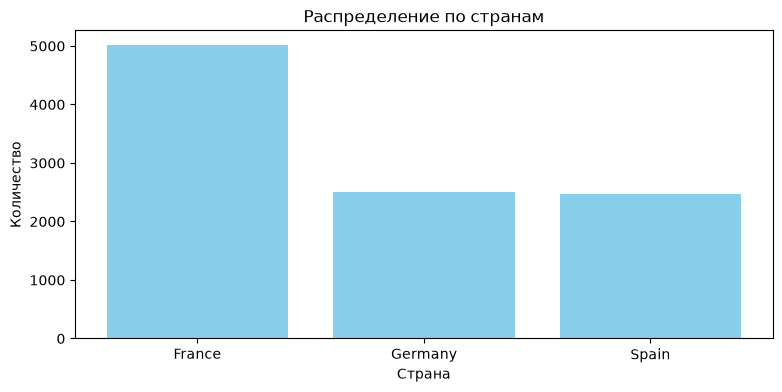

In [6]:
# Создадим диаграмму
plt.figure(figsize=(9, 4))
plt.bar(data["country"], data["count"], color='skyblue')
plt.xlabel("Страна")
plt.ylabel("Количество")
plt.title("Распределение по странам")
plt.show()

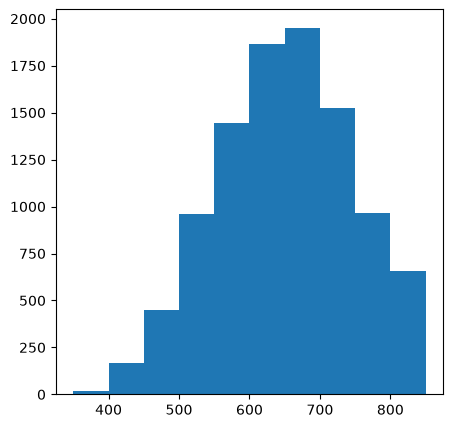

In [7]:
plt.figure(figsize=(5, 5))
plt.hist(df["credit_score"])
plt.show()

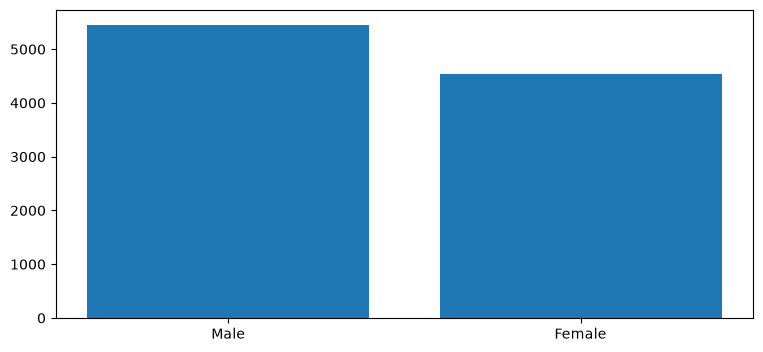

In [8]:
# Создадим диаграмму по полам
gender_counts = df["gender"].value_counts()
plt.figure(figsize=(9, 4))
plt.bar(gender_counts.index, gender_counts.values)
plt.show()

In [9]:
**Отдельно обрати внимание на:**
- `age`
- `credit_score`
- `balance`
- `estimated_salary`
- `tenure`
- `products_number`

Посмотри их `min / max / mean / median / std`.

SyntaxError: invalid syntax (1408173107.py, line 1)

In [10]:
df["age"].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: age, dtype: float64

In [11]:
df["credit_score"].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: credit_score, dtype: float64

In [12]:
df["balance"].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: balance, dtype: float64

In [13]:
df["estimated_salary"].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: estimated_salary, dtype: float64

In [14]:
df["tenure"].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: tenure, dtype: float64

In [15]:
df["products_number"].describe()

count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: products_number, dtype: float64

In [16]:
left_counts = df["churn"].value_counts()
print(f"Ушли: {left_counts.get(1, 0)}")
print(f"Остались: {left_counts.get(0, 0)}")
print(f"Процент ушедших: {left_counts.get(1, 0) / left_counts.sum() * 100:.2f}%")

Ушли: 2037
Остались: 7963
Процент ушедших: 20.37%


In [19]:
# 3–5 признаков, которые потенциально могут быть связаны с уходом клиента**, ещё до построения графиков.
# 1) Возраст
# 2) Низский balance
# 3) Страна

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


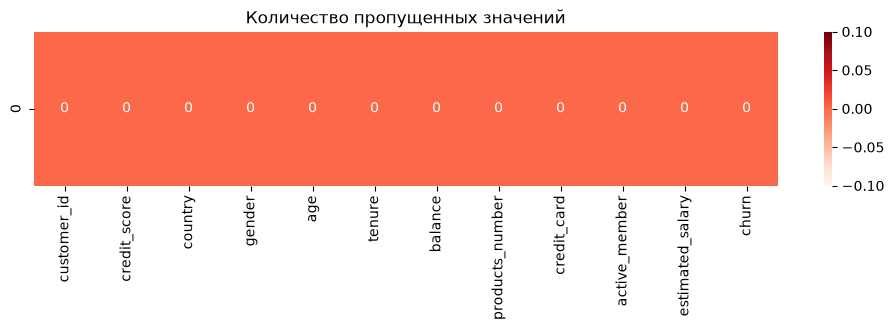

In [18]:
missing = df.isna().sum()

print(missing)

plt.figure(figsize=(12, 2))
sns.heatmap(
    missing.to_frame().T,
    annot=True,
    fmt="d",
    cmap="Reds"
)
plt.title("Количество пропущенных значений")
plt.show()

In [20]:
print("Дубликаты строк:", df.duplicated().sum())
print("Повторяющиеся customer_id:", df["customer_id"].duplicated().sum())

Дубликаты строк: 0
Повторяющиеся customer_id: 0


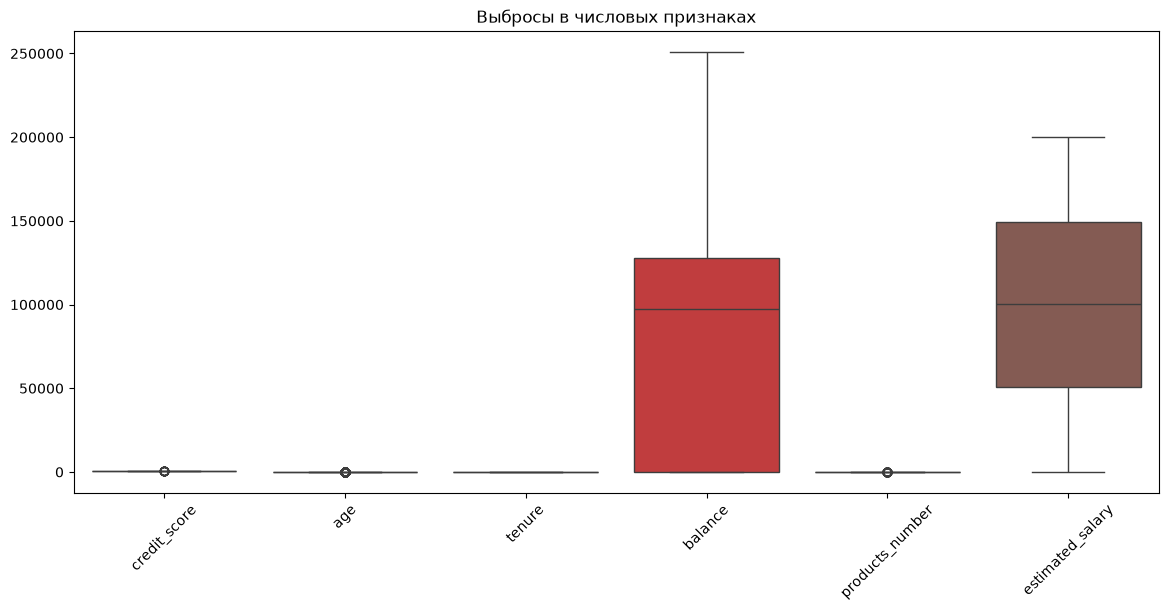

In [25]:
numeric_cols = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

df[numeric_cols].describe().T
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Выбросы в числовых признаках")
plt.show()

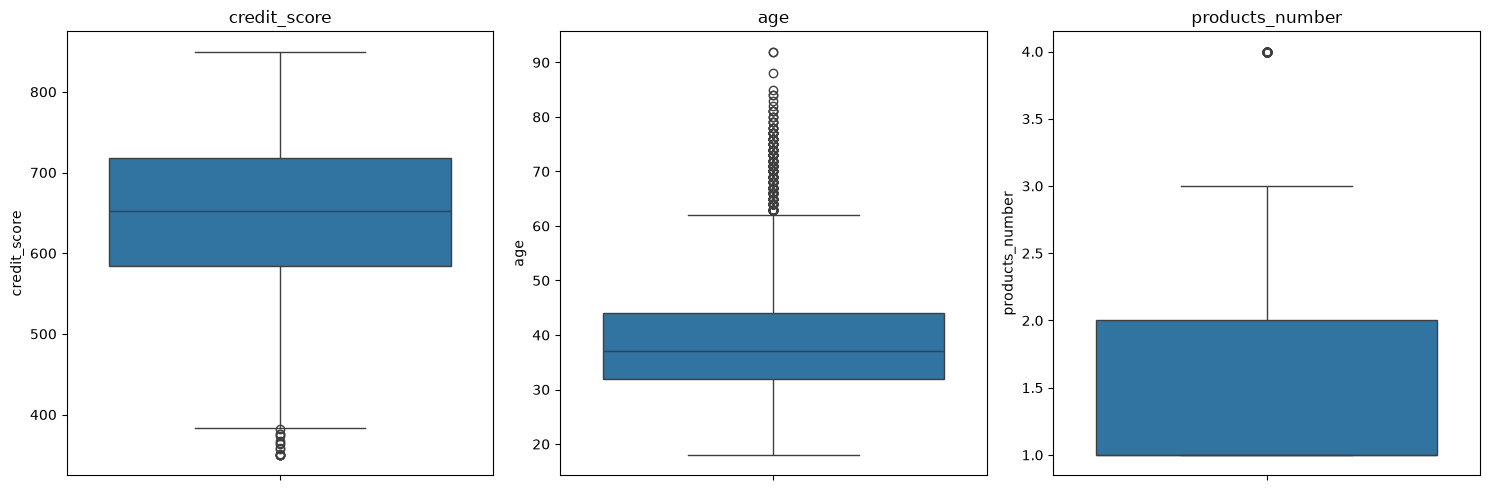

In [26]:
cols = ["credit_score", "age", "products_number"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

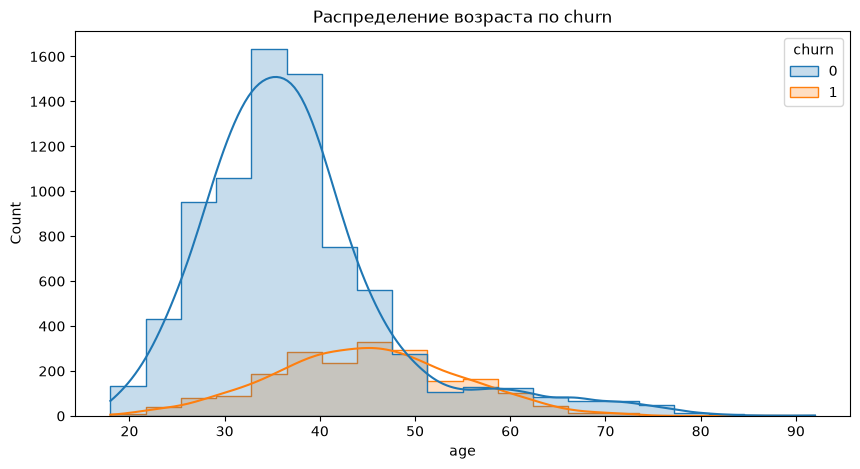

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=20,
    kde=True,
    element="step",
    common_norm=False
)

plt.title("Распределение возраста по churn")
plt.show()

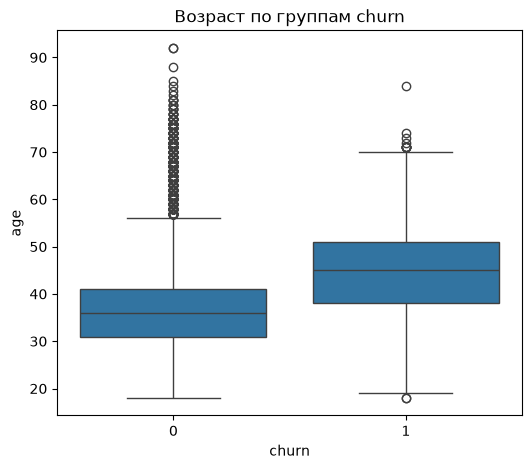

In [28]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df,
    x="churn",
    y="age"
)
plt.title("Возраст по группам churn")
plt.show()

In [29]:
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "66+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)
age_churn = (
    df.groupby("age_group", observed=False)
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
)

age_churn["churn_percent"] *= 100
age_churn

,clients,churn_count,churn_percent
age_group,,,
18–25,611,46,7.528642
26–35,3542,301,8.498024
36–45,3736,733,19.619914
46–55,1311,663,50.572082
56–65,536,259,48.320896
66+,264,35,13.257576


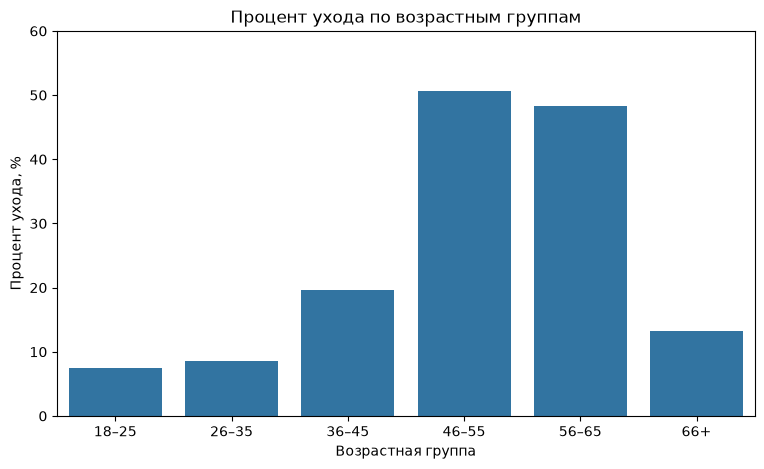

In [30]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=age_churn.reset_index(),
    x="age_group",
    y="churn_percent"
)
plt.title("Процент ухода по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Процент ухода, %")
plt.ylim(0, 60)
plt.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-174' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/b3bry4/projects/EDA/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-175' coro=<Kernel.shell_main() running at /Users/b3bry4/projects/EDA/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/b3bry4/projects/EDA/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/b3bry4/projects/EDA/.venv/lib/python3.14/site-packages/pandas/core/flags.py:65: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  self._obj = weakref.ref(obj)
Task was destroyed but it is pending!
task: <Task pending name='Task-175' coro=<Kernel.shell_main() running at /Users/b3bry4/projects/EDA/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


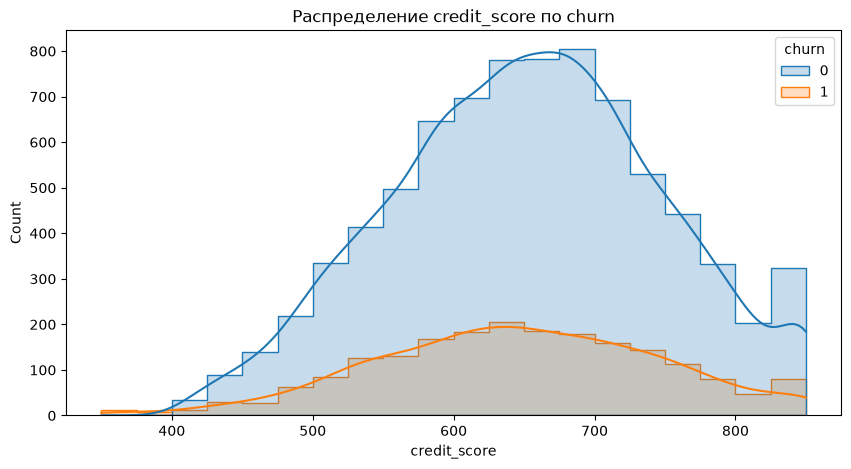

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="credit_score",
    hue="churn",
    bins=20,
    kde=True,
    element="step",
    common_norm=False
)
plt.title("Распределение credit_score по churn")
plt.show()

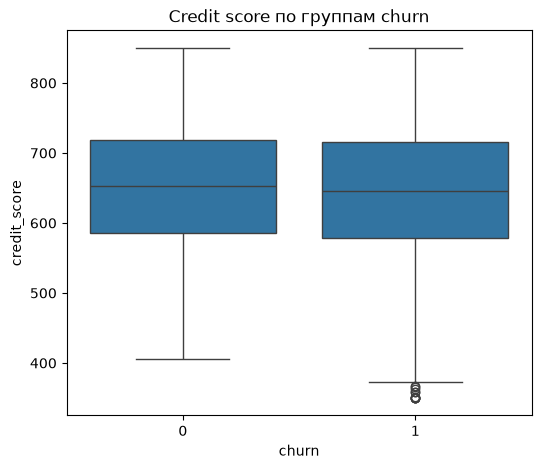

In [32]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df,
    x="churn",
    y="credit_score"
)
plt.title("Credit score по группам churn")
plt.show()

In [33]:
bins = [-float("inf"), 500, 600, 700, 800, float("inf")]
labels = ["<500", "500–600", "600–700", "700–800", "800+"]
df["credit_score_group"] = pd.cut(
    df["credit_score"],
    bins=bins,
    labels=labels
)
credit_score_churn = (
    df.groupby("credit_score_group", observed=False)
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
  )

credit_score_churn["churn_percent"] *= 100
credit_score_churn

,clients,churn_count,churn_percent
credit_score_group,,,
<500,643,152,23.639191
500–600,2423,513,21.172101
600–700,3818,753,19.722368
700–800,2471,492,19.910967
800+,645,127,19.689922


In [34]:
country_churn = (
    df.groupby("country")
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
  )

country_churn["churn_percent"] *= 100
country_churn

,clients,churn_count,churn_percent
country,,,
France,5014,810,16.154767
Germany,2509,814,32.443204
Spain,2477,413,16.673395


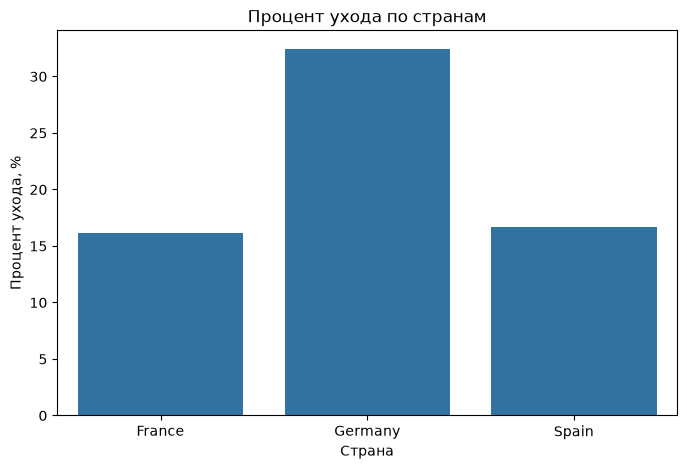

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=country_churn.reset_index(),
    x="country",
    y="churn_percent"
)

plt.title("Процент ухода по странам")
plt.xlabel("Страна")
plt.ylabel("Процент ухода, %")
plt.show()

In [38]:
df["balance_group"] = np.where(
    df["balance"] == 0,
    "Нулевой баланс",
    "Ненулевой баланс"
)

balance_churn = (
    df.groupby("balance_group")
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
  )

balance_churn["churn_percent"] *= 100
balance_churn

,clients,churn_count,churn_percent
balance_group,,,
Ненулевой баланс,6383,1537,24.079586
Нулевой баланс,3617,500,13.823611


In [39]:
bins = [-1, 0, 50_000, 100_000, 150_000, 200_000, float("inf")]
labels = [
    "0",
    "1–50 тыс.",
    "50–100 тыс.",
    "100–150 тыс.",
    "150–200 тыс.",
    "200 тыс.+"
]

df["balance_range"] = pd.cut(
    df["balance"],
    bins=bins,
    labels=labels
)

balance_ranges = (
    df.groupby("balance_range", observed=False)
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
  )

balance_ranges["churn_percent"] *= 100
balance_ranges

,clients,churn_count,churn_percent
balance_range,,,
0,3617,500,13.823611
1–50 тыс.,75,26,34.666667
50–100 тыс.,1509,300,19.880716
100–150 тыс.,3830,987,25.770235
150–200 тыс.,935,205,21.925134
200 тыс.+,34,19,55.882353


In [40]:
products_churn = (
    df.groupby("products_number")
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
)
products_churn["churn_percent"] *= 100
products_churn

,clients,churn_count,churn_percent
products_number,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


In [41]:
active_churn = (
    df.groupby("active_member")
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
)

active_churn["churn_percent"] *= 100
active_churn

,clients,churn_count,churn_percent
active_member,,,
0,4849,1302,26.850897
1,5151,735,14.269074


In [42]:
credit_card_churn = (
    df.groupby("credit_card")
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
)

credit_card_churn["churn_percent"] *= 100
credit_card_churn

,clients,churn_count,churn_percent
credit_card,,,
0,2945,613,20.814941
1,7055,1424,20.184266


In [43]:
bins = [-1, 2, 5, 10]
labels = ["0–2 года", "3–5 лет", "6–10 лет"]
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels
)

tenure_churn = (
    df.groupby("tenure_group", observed=False)
        .agg(
            clients=("churn", "size"),
            churn_count=("churn", "sum"),
            churn_percent=("churn", "mean")
        )
)
tenure_churn["churn_percent"] *= 100
tenure_churn

,clients,churn_count,churn_percent
tenure_group,,,
0–2 года,2496,528,21.153846
3–5 лет,3010,625,20.764120
6–10 лет,4494,884,19.670672


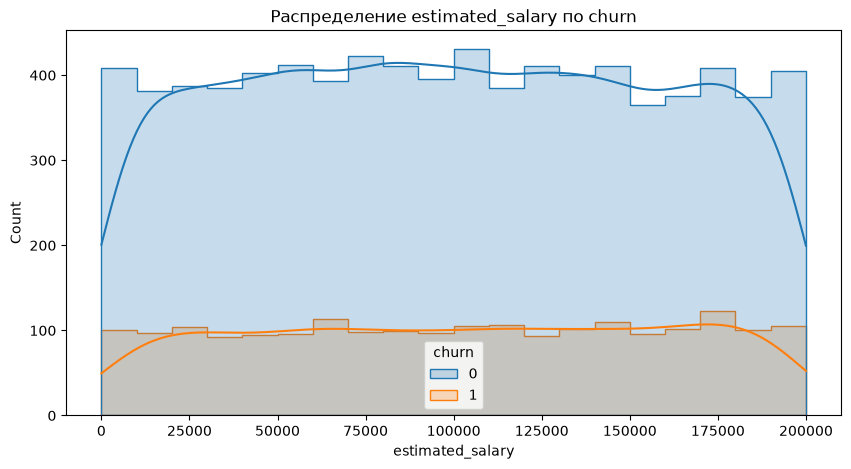

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="estimated_salary",
    hue="churn",
    bins=20,
    kde=True,
    element="step",
    common_norm=False
)
plt.title("Распределение estimated_salary по churn")
plt.show()

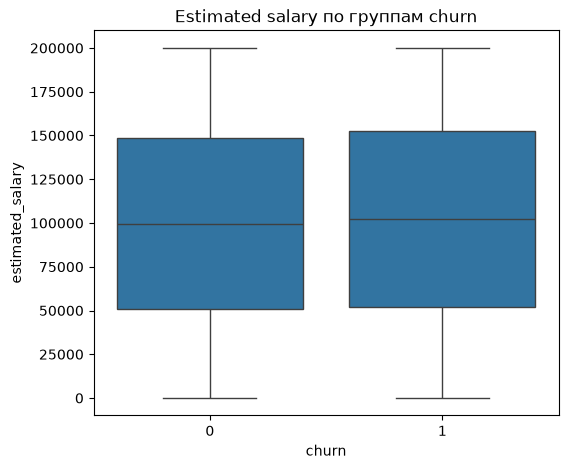

In [45]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df,
    x="churn",
    y="estimated_salary"
)
plt.title("Estimated salary по группам churn")
plt.show()

In [46]:
age_active_churn = (
    df.groupby(["age_group", "active_member"], observed=False)["churn"]
      .mean()
      .mul(100)
      .unstack()
)

age_active_churn.columns = ["Неактивные", "Активные"]

age_active_churn

,Неактивные,Активные
age_group,,
18–25,11.111111,4.334365
26–35,10.804598,6.270810
36–45,24.215938,14.628699
46–55,63.609023,37.151703
56–65,93.854749,25.490196
66+,62.500000,6.465517


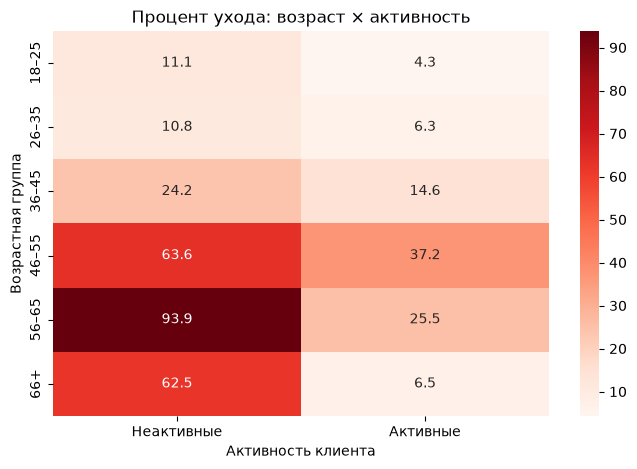

In [48]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    age_active_churn,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Процент ухода: возраст × активность")
plt.xlabel("Активность клиента")
plt.ylabel("Возрастная группа")
plt.show()

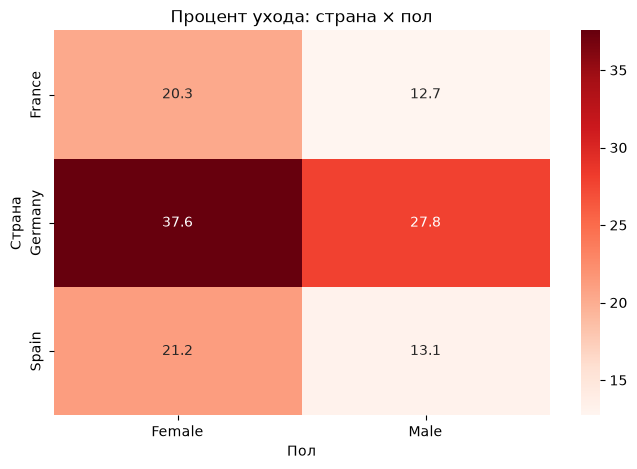

In [49]:
country_gender_churn = (
    df.groupby(["country", "gender"])["churn"]
    .mean()
    .mul(100)
    .unstack()
)

country_gender_churn
plt.figure(figsize=(8, 5))
sns.heatmap(
    country_gender_churn,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Процент ухода: страна × пол")
plt.xlabel("Пол")
plt.ylabel("Страна")
plt.show()

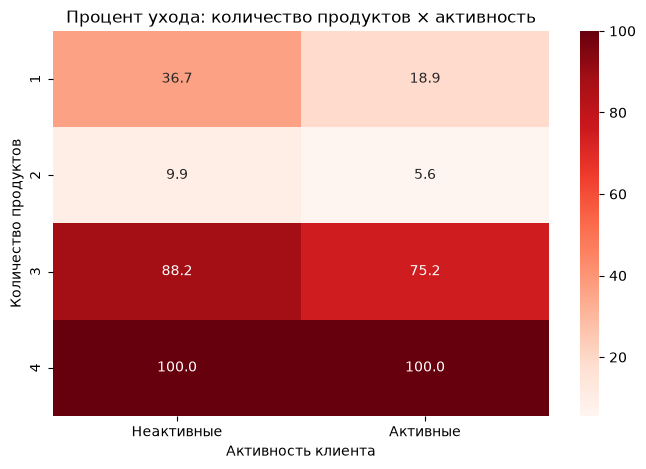

In [50]:
products_active_churn = (
    df.groupby(["products_number", "active_member"])["churn"]
    .mean()
    .mul(100)
    .unstack()
)
products_active_churn.columns = ["Неактивные", "Активные"]
products_active_churn
plt.figure(figsize=(8, 5))
sns.heatmap(\
    products_active_churn,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Процент ухода: количество продуктов × активность")
plt.xlabel("Активность клиента")
plt.ylabel("Количество продуктов")
plt.show()

In [51]:
df.groupby(["products_number", "active_member"]).agg(
    clients=("churn", "size"),
    churn_count=("churn", "sum")
)

clients  churn_count
products_number active_member                      
1               0                 2521          924
                1                 2563          485
2               0                 2144          212
                1                 2446          136
3               0                  153          135
                1                  113           85
4               0                   31           31
                1                   29           29

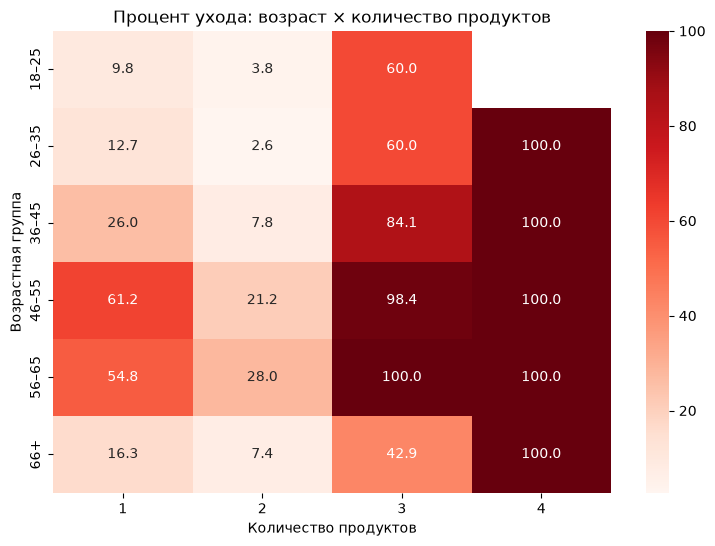

In [52]:
age_products_churn = (
    df.groupby(["age_group", "products_number"], observed=False)["churn"]
    .mean()
    .mul(100)
    .unstack()
)
age_products_churn
plt.figure(figsize=(9, 6))
sns.heatmap(
    age_products_churn,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Процент ухода: возраст × количество продуктов")
plt.xlabel("Количество продуктов")
plt.ylabel("Возрастная группа")
plt.show()

Выводы
Чаще всего уходят клиенты в возрасте 46–65 лет.
В Германии клиентов уходит заметно больше.
Неактивные клиенты уходят чаще активных.
Женщины уходят чаще мужчин.
Клиенты с ненулевым балансом уходят чаще клиентов с нулевым.
Самый низкий уход у клиентов с 2 продуктами.
У клиентов с 3–4 продуктами уход очень высокий.
Зарплата и наличие кредитной карты почти не связаны с уходом.
Кредитный рейтинг и стаж клиента влияют слабо.